## Fraud Detection

## STEP 1 — Import Libraries

In [15]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## STEP 2 — Load & Understand the Data

In [16]:
df = pd.read_csv('fraud_detection_dataset.csv')

print(df.head())            # first 5 rows

   TransactionID  Amount  Time   Location  Merchant DeviceType  Fraud
0              1   78325     9    Chennai  Flipkart     Mobile      0
1              2   10337    18  Hyderabad     Paytm     Tablet      0
2              3   53189    19    Chennai    Amazon     Tablet      0
3              4   22970    22      Delhi   Unknown     Tablet      0
4              5   13444    22      Delhi   Unknown     Tablet      0


In [17]:
print(df.shape)             # (1000, 7)

(1000, 7)


In [18]:
print(df.dtypes)            # column types

TransactionID     int64
Amount            int64
Time              int64
Location         object
Merchant         object
DeviceType       object
Fraud             int64
dtype: object


In [19]:
print(df.describe())        # statistics

       TransactionID        Amount        Time       Fraud
count    1000.000000   1000.000000  1000.00000  1000.00000
mean      500.500000  49647.679000    11.85900     0.21600
std       288.819436  28604.260852     7.08995     0.41172
min         1.000000    102.000000     0.00000     0.00000
25%       250.750000  24311.750000     6.00000     0.00000
50%       500.500000  51135.500000    12.00000     0.00000
75%       750.250000  73714.250000    18.00000     0.00000
max      1000.000000  99963.000000    23.00000     1.00000


In [20]:
print(df.isnull().sum())    # missing values


TransactionID    0
Amount           0
Time             0
Location         0
Merchant         0
DeviceType       0
Fraud            0
dtype: int64


In [21]:
print(df['Fraud'].value_counts())  # how many fraud vs not fraud

Fraud
0    784
1    216
Name: count, dtype: int64


## STEP 3 — Exploratory Data Analysis (EDA)

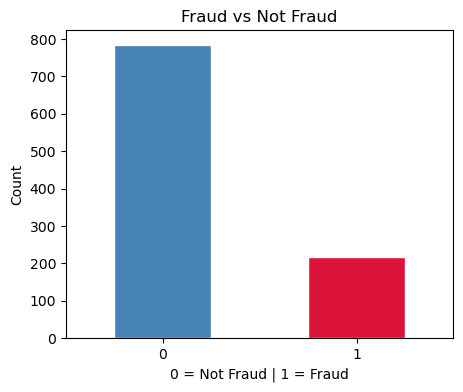

In [22]:
# Fraud vs Not Fraud count
plt.figure(figsize=(5,4))
df['Fraud'].value_counts().plot(kind='bar', color=['steelblue','crimson'], edgecolor='white')
plt.title('Fraud vs Not Fraud')
plt.xlabel('0 = Not Fraud | 1 = Fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

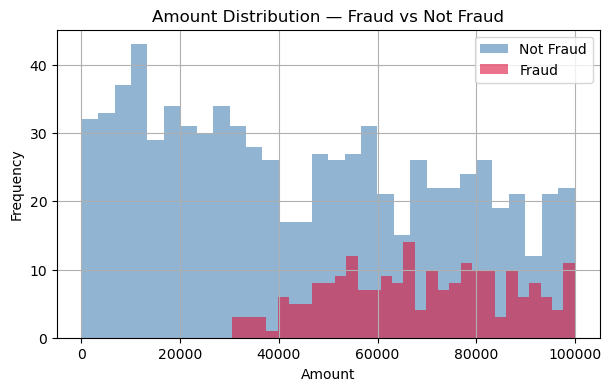

In [23]:
# Amount distribution by Fraud
plt.figure(figsize=(7,4))
df[df['Fraud']==0]['Amount'].hist(bins=30, alpha=0.6, color='steelblue', label='Not Fraud')
df[df['Fraud']==1]['Amount'].hist(bins=30, alpha=0.6, color='crimson', label='Fraud')
plt.title('Amount Distribution — Fraud vs Not Fraud')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

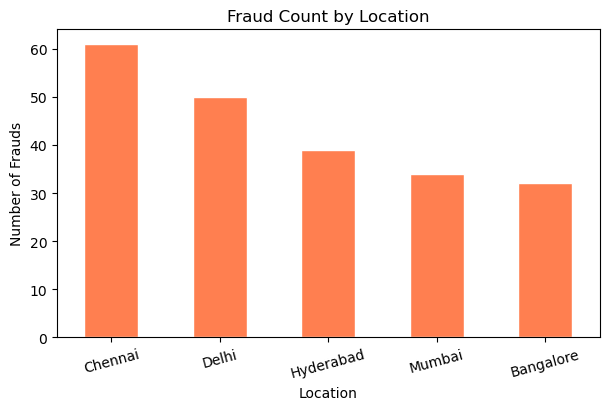

In [24]:
# Fraud count by Location
plt.figure(figsize=(7,4))
df.groupby('Location')['Fraud'].sum().sort_values(ascending=False).plot(
    kind='bar', color='coral', edgecolor='white')
plt.title('Fraud Count by Location')
plt.ylabel('Number of Frauds')
plt.xticks(rotation=15)
plt.show()

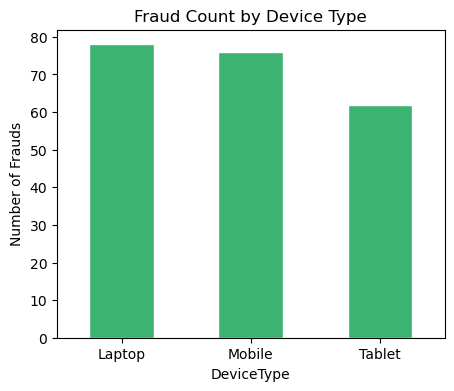

In [25]:
# Fraud count by DeviceType
plt.figure(figsize=(5,4))
df.groupby('DeviceType')['Fraud'].sum().plot(
    kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Fraud Count by Device Type')
plt.ylabel('Number of Frauds')
plt.xticks(rotation=0)
plt.show()

## STEP 4 — Data Preprocessing

In [26]:
# Drop TransactionID — just a serial number, useless for prediction
df = df.drop(columns=['TransactionID'])

# One-Hot Encode all 3 categorical columns
df = pd.get_dummies(df, columns=['Location', 'Merchant', 'DeviceType'], drop_first=True)



In [27]:
print(df.head())

   Amount  Time  Fraud  Location_Chennai  Location_Delhi  Location_Hyderabad  \
0   78325     9      0              True           False               False   
1   10337    18      0             False           False                True   
2   53189    19      0              True           False               False   
3   22970    22      0             False            True               False   
4   13444    22      0             False            True               False   

   Location_Mumbai  Merchant_Flipkart  Merchant_Myntra  Merchant_Paytm  \
0            False               True            False           False   
1            False              False            False            True   
2            False              False            False           False   
3            False              False            False           False   
4            False              False            False           False   

   Merchant_Unknown  DeviceType_Mobile  DeviceType_Tablet  
0             

In [28]:
print(df.shape)

(1000, 13)


In [29]:
print(df.columns.tolist())

['Amount', 'Time', 'Fraud', 'Location_Chennai', 'Location_Delhi', 'Location_Hyderabad', 'Location_Mumbai', 'Merchant_Flipkart', 'Merchant_Myntra', 'Merchant_Paytm', 'Merchant_Unknown', 'DeviceType_Mobile', 'DeviceType_Tablet']


## STEP 5 — Split Features & Target, Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Fraud'])   # all columns except Fraud
y = df['Fraud']                  # only the Fraud column

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows :", X_train.shape[0])
print("Testing rows  :", X_test.shape[0])

Training rows : 800
Testing rows  : 200


## STEP 6 — Build & Train the Models

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Note: Using Classifiers now (not Regressors like house prices!)
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully


## STEP 7 — Evaluate the Models

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n {name}")
    print(f"   Accuracy : {acc*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))


 Logistic Regression
   Accuracy : 87.50%
              precision    recall  f1-score   support

   Not Fraud       0.89      0.95      0.92       149
       Fraud       0.82      0.65      0.73        51

    accuracy                           0.88       200
   macro avg       0.86      0.80      0.82       200
weighted avg       0.87      0.88      0.87       200


 Decision Tree
   Accuracy : 100.00%
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00       149
       Fraud       1.00      1.00      1.00        51

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


 Random Forest
   Accuracy : 100.00%
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00       149
       Fraud       1.00      1.00      1.00        51

    accuracy                           1.00       200
   macro 

## STEP 8 — Confusion Matrix (Visual)

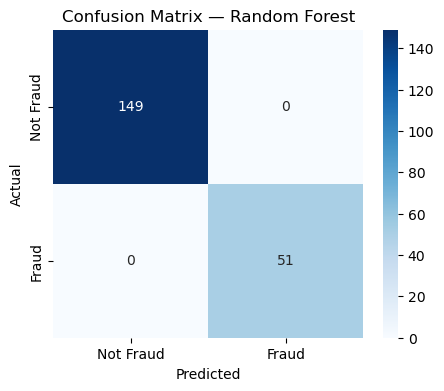

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model = models['Random Forest']
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## STEP 9 — Feature Importance

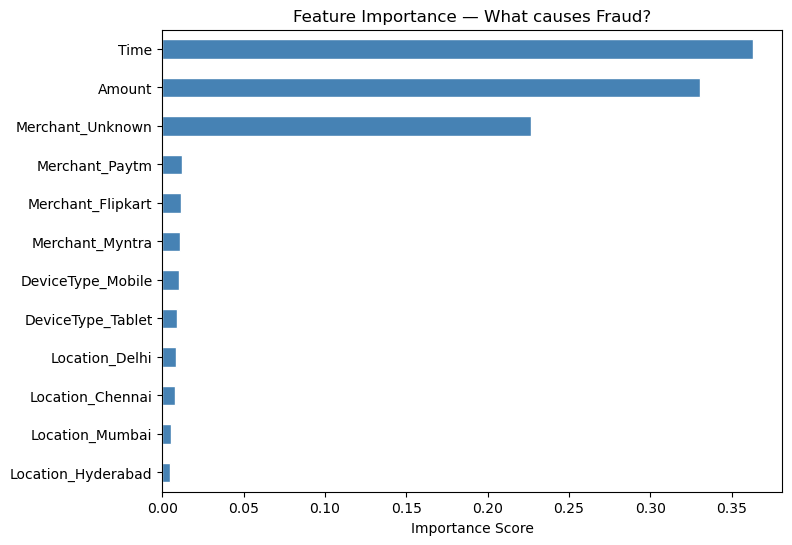

In [37]:
import pandas as pd

best_model = models['Random Forest']

feat_imp = pd.Series(best_model.feature_importances_,
                     index=X.columns).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8,6), color='steelblue', edgecolor='white')
plt.title('Feature Importance — What causes Fraud?')
plt.xlabel('Importance Score')
plt.show()

## STEP 10 — Predict on a New Transaction

In [40]:
# Example: New transaction to check if it's fraud
new_transaction = pd.DataFrame([{
    'Amount': 95000,
    'Time'  : 2,
}])

# Add all the encoded columns with 0s (adjust based on your actual columns)
for col in X.columns:
    if col not in new_transaction.columns:
        new_transaction[col] = 0

new_transaction = new_transaction[X.columns]

prediction = best_model.predict(new_transaction)[0]
print(" Transaction Result:", " FRAUD!" if prediction == 1 else " Not Fraud")

 Transaction Result:  FRAUD!
